# CareerAI Agent — External Debug Notebook (convergence engine)

Step-by-step debugger for the auto-apply agent on **any external ATS**
(Greenhouse, Lever, Ashby, SuccessFactors, custom, and Workday-*style* portals
like HPE). This is the same mature, deterministic-first flow used in
`debug_workday.ipynb`, generalized — it drives `apply_engine.converge_page()`
instead of the old `plan_page` / Step-A+Step-B LLM planner.

**How to use:** open in VS Code, change `URL` in the *Open the page* cell to the
job/application page you want, then run cells top-to-bottom with **Shift+Enter**.

Pipeline:
1. **Open** the page in a persistent Chromium profile (cookies carry over).
2. **Settle / Scan / Set-of-marks** — wait for the DOM to stop mutating, collect
   every interactive element with `data-agent-idx`, draw the red numbered boxes.
3. **Gateway pass** — deterministically clear cookie/modal overlays, then ONE
   trimmed LLM call to detect a landing/gateway page and click its *Apply* button
   (following the new tab into the real ATS). No field-filling here.
4. **Auto-reveal loop** — expand multi-row Work Experience / Education sections
   so every row exists before we fill (section-label + profile-count driven).
5. **Convergence fill** — `converge_page()` fills every field from the profile
   (deterministic → LLM-resolver → hold), clicks *Save & Continue*, and uses the
   page's OWN validation errors as the to-do list, refilling only what errored
   until the page advances or a field genuinely needs you.
6. **Loop** — re-run scan → reveal → converge per page until *Submit*.
7. **Cleanup**.

Run order per page: **Scan → Gateway (first page only) → Auto-reveal → Converge.**


In [1]:
import os, sys, json, base64, asyncio, threading
from pathlib import Path
from concurrent.futures import Future

# Jupyter on Windows runs a SelectorEventLoop (Tornado), which cannot spawn
# subprocesses -> Playwright's driver fails to launch. Workaround: run all
# Playwright coroutines on a dedicated background thread whose loop is a
# ProactorEventLoop. (On macOS/Linux the default loop already works.)
class _AsyncRunner:
    def __init__(self):
        if sys.platform == "win32":
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        self.loop = asyncio.new_event_loop()
        self._ready = threading.Event()
        self.thread = threading.Thread(target=self._serve, daemon=True)
        self.thread.start()
        self._ready.wait()

    def _serve(self):
        asyncio.set_event_loop(self.loop)
        self._ready.set()
        self.loop.run_forever()

    def run(self, coro):
        return asyncio.run_coroutine_threadsafe(coro, self.loop).result()

    def stop(self):
        self.loop.call_soon_threadsafe(self.loop.stop)

# Singleton: reuse across cells so `page` etc. stay bound to the same loop.
_BG = globals().get("_BG") or _AsyncRunner()
R   = _BG.run

# Make the project importable when launching from inside this folder.
sys.path.insert(0, str(Path.cwd()))

from dotenv import load_dotenv
load_dotenv()

# Generic agent helpers (shared with debug_workday.ipynb).
from auto_agent import (
    settle, collect_elements, elements_to_text, annotate_screenshot,
    execute_action, switch_if_new_tab, dismiss_overlays, clear_blocking_overlays,
    FLASH_MODEL,
)
# The mature convergence engine — the same one debug_workday.ipynb drives.
from apply_engine import converge_page, resolve_field
from profile_manager import load_profile, get_field_value, update_field, save_profile
from apply_llm import llm_json
from job_wiki import get_portal_knowledge

from IPython.display import Image, display

# One Gemini client reused by the gateway / reveal / converge cells (apply_llm
# routes to the real driver from APPLY_LLM, but the signatures want a client).
from google import genai
gemini_client = globals().get("gemini_client") or genai.Client(api_key=os.getenv("GEMINI_API_KEY", ""))

print("LLM driver :", os.getenv("APPLY_LLM"), "·", os.getenv("APPLY_MODEL"))
print("Email      :", (os.getenv("APPLY_EMAIL") or "")[:3] + "***")
print("CWD        :", Path.cwd())
print("Async loop :", type(_BG.loop).__name__, "(thread alive:", _BG.thread.is_alive(), ")")

LLM driver : openai · gpt-5.4-mini
Email      : dee***
CWD        : /Users/sakshi/Project/Resume_Builder
Async loop : _UnixSelectorEventLoop (thread alive: True )


### Reload modules — run this after editing any .py file

Jupyter caches imports. After editing `apply_engine.py` / `auto_agent.py` /
`workday.py`, run this cell to pick up the new code **without restarting the
kernel** (which would lose your live browser page state). Order matters: reload
leaf modules before the ones that import them.

In [2]:
# Reload ALL project modules after editing any .py file (no kernel restart).
import importlib
import profile_manager, workday, apply_skills.base, auto_agent, apply_engine
for _m in (profile_manager, workday, apply_skills.base, auto_agent, apply_engine):
    importlib.reload(_m)

# Re-pull every symbol the notebook cells use so they bind to the freshly
# reloaded functions (NOT the stale ones imported at startup).
from auto_agent import (settle, collect_elements, elements_to_text,
                        annotate_screenshot, execute_action, switch_if_new_tab,
                        dismiss_overlays, clear_blocking_overlays, FLASH_MODEL)
from apply_engine import converge_page, resolve_field
from profile_manager import load_profile, get_field_value, update_field, save_profile
from apply_llm import llm_json
print("Reloaded: profile_manager, workday, apply_skills.base, auto_agent, apply_engine")

Reloaded: profile_manager, workday, apply_skills.base, auto_agent, apply_engine


## 1. Open the page

We launch Chromium with the **same persistent profile** the real agent uses
(`browser_profile/`), so any session cookies you already have will apply.
The browser opens visibly on your screen — you can watch the page load.

In [3]:
from playwright.async_api import async_playwright

URL = "https://careers.hpe.com/us/en/apply?jobSeqNo=HPE1US1207415EXTERNALENUS&utm_source=linkedin&step=1"  # ← change me
PROFILE_DIR = Path("browser_profile")

_p  = R(async_playwright().start())
ctx = R(_p.chromium.launch_persistent_context(
    str(PROFILE_DIR),
    headless=False,
    args=["--disable-blink-features=AutomationControlled", "--no-sandbox"],
    viewport={"width": 1280, "height": 900},
))
page = ctx.pages[0] if ctx.pages else R(ctx.new_page())
R(page.goto(URL, wait_until="domcontentloaded"))
print("URL  :", page.url)
print("Title:", R(page.title()))


URL  : https://careers.hpe.com/us/en/apply?jobSeqNo=HPE1US1207415EXTERNALENUS&utm_source=linkedin&step=1
Title: Apply


## 2. Settle-gate

Web forms render asynchronously — fields appear / shift after the first paint.
If we read the DOM mid-render, our indices may be stale by the time the LLM
answers. `settle()` waits until **the network is idle AND the DOM stops
mutating for ~500ms.**

In [4]:
R(settle(page))
print("Settled.")
import time
time.sleep(4)


Settled.


## 3. Scan the DOM

`collect_elements()` runs a JavaScript pass (`_COLLECT_JS` in `auto_agent.py`)
that:

- Pierces **shadow roots** (modern web components hide their fields there).
- Picks every visible `input`, `textarea`, `select`, `button`,
  `[role=button|checkbox|radio]`, and `[contenteditable]`.
- Derives a **label** in this priority order: `aria-label` → `aria-labelledby`
  → `label[for=id]` → wrapping `<label>` → nearby preceding text → `name` attr.
- Records the **viewport box** `[x, y, w, h]` (used to draw the red marks).
- Tags **widget type**: native `<select>` → `select`; `role=combobox` /
  `aria-autocomplete` / `aria-haspopup=listbox` → `typeahead`.
- Injects `data-agent-idx="N"` so we can later target the element with a
  stable CSS selector regardless of how it's nested.

`idx_frame` maps each element's `idx` to the Playwright frame it lives in —
important because many ATS pages live inside iframes.

In [5]:
elements, idx_frame = R(collect_elements(page))
print(f"Found {len(elements)} interactive elements.\n")
for e in elements[:10]:
    print(e)
print("\n...(showing first 10)")


Found 61 interactive elements.

{'idx': 0, 'tag': 'a', 'type': None, 'label': '', 'box': [73, 2, 104, 76]}
{'idx': 1, 'tag': 'a', 'type': None, 'label': 'Close', 'box': [1320, 0, 108, 80]}
{'idx': 2, 'tag': 'a', 'type': None, 'label': 'Home', 'box': [68, 106, 51, 51]}
{'idx': 3, 'tag': 'button', 'type': None, 'label': 'Careers', 'box': [139, 107, 97, 51], 'widget': 'typeahead'}
{'idx': 4, 'tag': 'button', 'type': None, 'label': 'Teams', 'box': [256, 107, 86, 51], 'widget': 'typeahead'}
{'idx': 5, 'tag': 'a', 'type': None, 'label': 'Explore life, culture and benefits at HPE', 'box': [362, 106, 64, 51]}
{'idx': 6, 'tag': 'a', 'type': None, 'label': 'Frequently asked questions and answers for HPE careers', 'box': [446, 106, 45, 51]}
{'idx': 7, 'tag': 'a', 'type': None, 'label': 'Search all HPE job openings', 'box': [512, 106, 104, 51]}
{'idx': 8, 'tag': 'a', 'type': None, 'label': 'Sign up to join the HPE Talent Community', 'box': [68, 158, 195, 51]}
{'idx': 9, 'tag': 'button', 'type': No

## 4. Set-of-marks — what the LLM "sees"

We draw a red numbered box on every element. **This is the screenshot the
LLM receives.** The numbers in the boxes are the `idx` values — the LLM
refers to elements by these in its plan ("fill `[5]` with 'Bengaluru'").

screenshot: 1280 x 2737 px  (1,039,988 bytes raw, 1,057,099 bytes marked)
elements: 61, y range: 0 to 2704


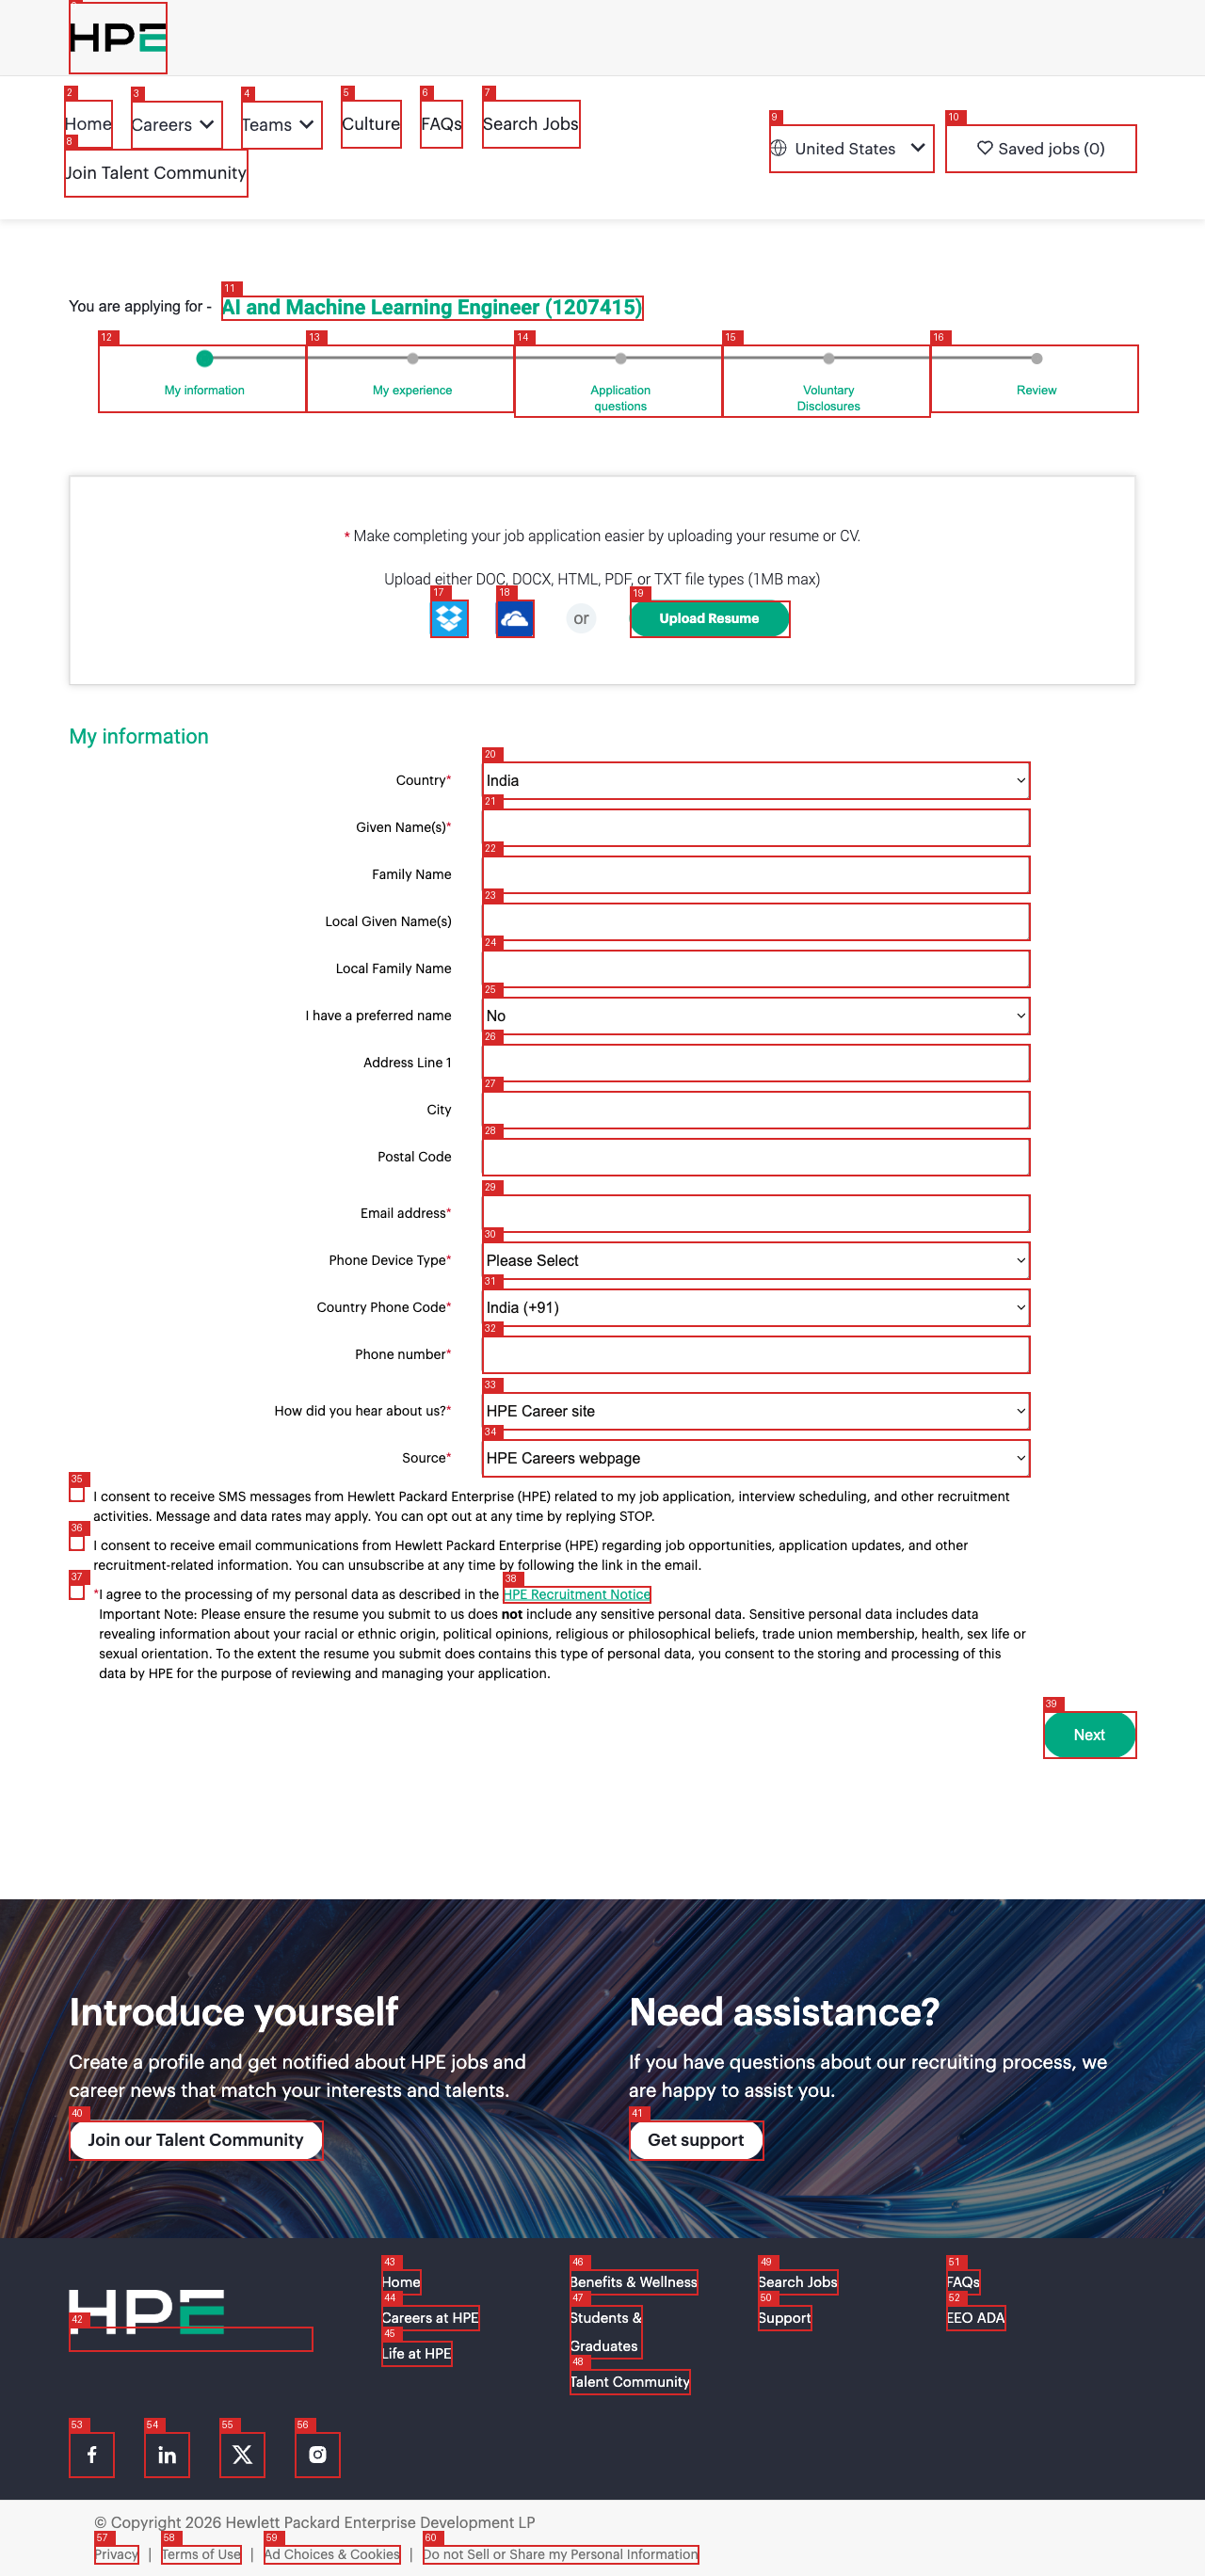

In [6]:
# Full-page, scroll-aware set-of-marks:
#   1. Scroll to top so getBoundingClientRect coords == document coords
#      (otherwise scrolled-out elements get negative y and the annotator
#      drops them, leaving a misleading half-picture for the LLM).
#   2. Re-scan elements at scrollY=0 so the boxes align with the document.
#   3. full_page=True stitches the entire scrollable area into one PNG.
R(page.evaluate("window.scrollTo(0, 0)"))
R(page.wait_for_timeout(400))   # let sticky headers / lazy renders settle
elements, idx_frame = R(collect_elements(page))

raw_png    = R(page.screenshot(full_page=True))
marked_png = annotate_screenshot(raw_png, elements)

# Quick stats so you can see what was captured.
from PIL import Image as _PI
import io as _io
_im = _PI.open(_io.BytesIO(raw_png))
print(f"screenshot: {_im.size[0]} x {_im.size[1]} px  ({len(raw_png):,} bytes raw, {len(marked_png):,} bytes marked)")
ys = [e["box"][1] for e in elements if e.get("box")]
print(f"elements: {len(elements)}, y range: {min(ys) if ys else 0} to {max(ys) if ys else 0}")

display(Image(data=marked_png))

## 5. Element-list text — the textual description

Alongside the screenshot, we send a structured **text list** of every
element. Look for the widget tags (`<typeahead>`, `<select>`), `REQUIRED`
markers, current values, and option lists — that's the model's "reading"
of the page.

In [7]:
elements_text = elements_to_text(elements)
print(elements_text)

[0] a
[1] a "Close"
[2] a "Home"
[3] button "Careers" <typeahead>
[4] button "Teams" <typeahead>
[5] a "Explore life, culture and benefits at HPE"
[6] a "Frequently asked questions and answers for HPE careers"
[7] a "Search all HPE job openings"
[8] a "Sign up to join the HPE Talent Community"
[9] button "Language selected English United States" <typeahead> (current: United States)
[10] a "saved jobs (0)"
[11] a "AI and Machine Learning Engineer (1207415)"
[12] li
[13] li
[14] li
[15] li
[16] li
[17] i "Dropbox"
[18] i "Microsoft online"
[19] button button "Upload Resume"
[20] select REQUIRED "Country *" <select> (current: IND) options: Please Select | Afghanistan | Åland Islands | Albania | Algeria | American Samoa | Andorra | Angola | Anguilla | Antigua and Barbuda | Argentina | Armenia | Aruba | Australia | Austria | Azerbaijan | Bahamas | Bahrain | Bangladesh | Barbados | Belarus | Belgium | Belize | Benin | Bermuda | Bhutan | Bolivia | Bonaire, Sint Eustatius, and Saba | Bosnia an

## 6. Profile — who we're applying as

`converge_page` loads the profile itself; this is just a read-only sanity check
of the values the engine will pull from. If a field looks wrong here, fix it in
the profile (or the resume) before running the convergence cell.

In [8]:
# Read-only profile snapshot (the engine re-loads it internally).
USER_ID     = 1
profile     = load_profile(USER_ID)
resume_text = profile.get("_resume_text", "")

print(f"first_name : {profile.get('first_name')!r}")
print(f"last_name  : {profile.get('last_name')!r}")
print(f"email      : {(os.getenv('APPLY_EMAIL') or profile.get('email') or '')!r}")
print(f"city       : {profile.get('city')!r}")
print(f"phone      : {profile.get('phone')!r}")
print(f"country    : {profile.get('country')!r}")
exp = profile.get('experience') or profile.get('work_experience') or []
edu = profile.get('education') or []
print(f"experience : {len(exp)} entr{'y' if len(exp) == 1 else 'ies'}")
print(f"education   : {len(edu)} entr{'y' if len(edu) == 1 else 'ies'}")
print(f"resume_text: {len(resume_text)} chars" + (" (EMPTY!)" if not resume_text else ""))

first_name : 'DEEPAK'
last_name  : 'KUMAR'
email      : 'deepakkumar007.jobs@gmail.com'
city       : 'Bengaluru'
phone      : '9780616787'
country    : 'India'
experience : 3 entries
education   : 2 entries
resume_text: 4590 chars


## 7. Gateway pass — clear overlays + click through landing pages

`converge_page` assumes you're already on a fillable form. External flows often
START on a job-description landing page (cookie banner + chatbot + an "Apply"
button that opens the real ATS in a new tab). This cell deterministically clears
overlays, then makes ONE trimmed LLM call to detect a gateway page and click its
*Apply* button, following the new tab — looping until we're on a form/login page.
No field-filling here; that's the convergence cell's job. On a page that's
already a form this is a no-op (page_type=form) — safe to run anyway.

In [9]:
# ── Gateway / overlay pass ───────────────────────────────────────────────
# converge_page assumes you're already on a fillable form. External flows
# often START on a job-description LANDING page (cookie banner + chatbot + an
# "Apply" button that opens the real ATS in a new tab). This cell:
#   1. deterministically clears overlays (dismiss_overlays + stuck backdrops),
#   2. makes ONE trimmed LLM call to classify the page and locate the Apply
#      button (NO field-filling — that's converge_page's job),
#   3. clicks it, follows the new tab, and repeats until we're on a form/login.
GATEWAY_PROMPT = """You are triaging ONE page in a job-application flow.
Red numbered boxes mark interactive elements (the number is each element's index).

Return STRICT JSON only:
{
  "page_type": "<gateway | form | login | other>",
  "summary":   "<one sentence>",
  "advance":   {"index": <int or null>, "label": "<button text or empty>"}
}

DEFINITIONS
- gateway = a landing / job-description page whose ONLY purpose is to send you
  forward. The action is a single button like "Apply", "Apply Now",
  "Apply Manually", "Start Application", "Continue to application". Put that
  button in `advance`.
- form  = a page with fields to fill (name / email / address / questions / upload).
- login = sign-in / create-account (email + password) page.
- other = none of the above.

Set advance.index ONLY for a gateway page; otherwise advance.index = null.
NEVER pick Sign Out, header nav, footer, language, social-share, or cookie
buttons. Return ONLY the JSON object."""

creds = {"email": os.getenv("APPLY_EMAIL", ""), "password": os.getenv("APPLY_PASSWORD", "")}

def _gateway_scan():
    R(dismiss_overlays(page)); R(clear_blocking_overlays(page)); R(settle(page))
    R(page.evaluate("window.scrollTo(0, 0)")); R(page.wait_for_timeout(300))
    elems, idx_fr = R(collect_elements(page))
    raw  = R(page.screenshot(full_page=True))
    mark = annotate_screenshot(raw, elems)
    info = llm_json(GATEWAY_PROMPT, image_b64=base64.b64encode(mark).decode(),
                    gemini_client=gemini_client, gemini_model=FLASH_MODEL)
    return info, elems, idx_fr

page_type = "other"
for _hop in range(1, 4):
    info, elements, idx_frame = _gateway_scan()
    page_type = (info or {}).get("page_type", "other")
    adv = (info or {}).get("advance") or {}
    print(f"hop {_hop}: page_type={page_type!r}  advance={adv}  ({(info or {}).get('summary','')[:70]})")
    if page_type != "gateway" or adv.get("index") is None:
        break
    before = page.url
    ok, note = R(execute_action(page, {"action": "click", "index": adv["index"],
                 "label": adv.get("label", "")}, idx_frame, elements, "", creds))
    print(f"  click [{adv['index']}] {adv.get('label','')!r}: {'OK' if ok else 'FAIL'} — {note}")
    R(page.wait_for_timeout(2500))
    np = R(switch_if_new_tab(ctx, page))
    if np is not page:
        print(f"  -> followed new tab: {np.url[:80]}")
        page = np
    R(settle(page))
    if page.url == before and np is page:
        print("  (no navigation; stopping gateway loop)")
        break

print(f"\nNow on : {page.url}")
print(f"Title  : {R(page.title())}")
print(f"page_type={page_type}  ->  run Auto-reveal then Convergence next.")

hop 1: page_type='form'  advance={'index': None, 'label': ''}  (This is an HPE job application form with personal information fields, )

Now on : https://careers.hpe.com/us/en/apply?jobSeqNo=HPE1US1207415EXTERNALENUS&utm_source=linkedin&step=1&stepname=personalInformation
Title  : Apply
page_type=form  ->  run Auto-reveal then Convergence next.


## 8. Auto-reveal loop — expand multi-row sections

Expand Work Experience / Education / Certifications rows so every row the profile
needs exists BEFORE we fill. Loops an LLM page-overview with a deterministic
profile-count check (want vs. visible rows), clicking each "Add" once per pass
and re-scanning, until reveals are exhausted, no progress is made, or MAX_PASSES.
Empty = single-row page (login/contact) — that's fine, just move on to converge.

In [ ]:
# Auto-reveal loop — expand multi-row sections (Work Experience / Education /
# Certifications) BEFORE we fill, so every row the profile needs actually
# exists on the page. Loops: page-overview (LLM) -> click each queued "Add"
# once -> re-scan, until no reveals remain, no progress is made, or MAX_PASSES.
# Generic across ATSes (Greenhouse/Lever/Workday-style all have repeatable rows).
import base64 as _b64
from google import genai as _genai
import apply_engine as _ae

MAX_PASSES = 6  # safety cap
_gc_auto = globals().get("gemini_client") or _genai.Client(
    api_key=os.getenv("GEMINI_API_KEY", ""))

def _profile_brief_auto(prof):
    parts = []
    exp = prof.get("experience") or prof.get("work_experience")
    if isinstance(exp, list):
        parts.append(f"{len(exp)} work experiences")
    elif prof.get("current_company"):
        yr = prof.get("years_experience") or "?"
        parts.append(f"current job: {prof.get('current_title','')} @ "
                     f"{prof['current_company']} ({yr} total experience)")
    edu = prof.get("education")
    if isinstance(edu, list):
        parts.append(f"{len(edu)} education entries: " +
                     ", ".join(f"{e.get('degree','?')} {e.get('institution','')}"
                               for e in edu))
    for k in ("certifications", "languages", "skills"):
        v = prof.get(k)
        if isinstance(v, list) and v:
            parts.append(f"{len(v)} {k}")
    return "; ".join(parts) if parts else "minimal profile, no structured lists"

def _build_overview_prompt(brief):
    return f"""Look at this job application page. Red numbered boxes mark interactive elements.

USER PROFILE BRIEF: {brief}

Return STRICT JSON only:
{{
  "page_type":  "<login | register | profile | work_experience | education | questions | review | gateway | other>",
  "summary":    "<1-2 sentence overview>",
  "fields":     ["<each visible field with current state>"],
  "buttons":    ["<each visible action button>"],
  "errors":     ["<inline error messages, if any>"],
  "plan":       "<1-2 sentence high-level plan>",
  "status":     "<more_to_fill | ready_to_advance | blocked_validation | submit_review | done>",
  "remaining":  ["<labels of empty REQUIRED fields, empty list if none>"],
  "reveal_actions": [
    {{"index": <int>, "label": "<button label>", "section": "<Work Experience | Education | Certifications | Languages>", "reason": "<why>"}}
  ],
  "row_mappings": [
    {{
      "section":          "<e.g. Work Experience 1 / Education 2 / Certification 3>",
      "profile_list":     "<one of: experience | education | certifications>",
      "profile_index":    <0-based int into that list>,
      "key_value":        "<visible identifying value>",
      "element_indices":  [<list of all red-box numbers that belong to this row>]
    }}
  ]
}}

ROW MAPPINGS: one per visible multi-row container. For EACH visible row
(Work Experience 1, Work Experience 2, Education 1, etc.):
- Identify visible identifying value (company name / institution name).
- Match against profile entries 0-based. Brief lists experience and
  education in order: experience: A, B, C -> A=0, B=1, C=2.
- List EVERY red-box number that belongs to that row.
- If no match in profile brief, set profile_index = -1.
- If no multi-row sections exist, return row_mappings = [].

REVEAL ACTIONS — clicks needed BEFORE filling fields. RETURN EXACTLY ONE
ENTRY PER MISSING ROW (do NOT collapse multiple rows of the same section
into a single 'Add x3' — the loop will re-call you after each click).
- "Add" / "Add Another" / "+ Add" / "Expand all sections": one entry.
- ALWAYS include the SECTION name (Work Experience / Education / etc.)
  to disambiguate identically-labelled buttons across sections.
- If section already shows N rows and brief wants N (or fewer), do NOT
  emit a reveal for that section.
- Do NOT include the page's main 'Save and Continue' / 'Submit' here.

STATUS rules:
- submit_review = LAST page; only button is 'Submit Application'.
- blocked_validation = visible inline errors.
- more_to_fill = any required field still empty.
- ready_to_advance = all required fields filled, has 'Save and Continue'/'Next'.
- done = nothing to do.
"""

def _run_overview_pass():
    """One overview pass. Returns the parsed overview dict."""
    R(page.evaluate("window.scrollTo(0, 0)"))
    R(page.wait_for_timeout(400))
    elems, idx_fr = R(collect_elements(page))
    _ae._assign_section_rows(elems)   # count un-numbered / auto-parsed rows too
    raw = R(page.screenshot(full_page=True))
    mark = annotate_screenshot(raw, elems)
    prof = load_profile(globals().get("USER_ID", 1))
    brief = _profile_brief_auto(prof)
    img_b64 = _b64.b64encode(mark).decode()
    ov = llm_json(_build_overview_prompt(brief),
                  image_b64=img_b64,
                  gemini_client=_gc_auto, gemini_model=FLASH_MODEL)
    globals()["elements"]            = elems
    globals()["idx_frame"]           = idx_fr
    globals()["marked_png"]          = mark
    globals()["last_overview"]       = ov
    globals()["last_status"]         = ov.get("status", "unknown")
    globals()["last_reveal_actions"] = ov.get("reveal_actions", []) or []
    globals()["last_remaining"]      = ov.get("remaining", []) or []
    globals()["last_row_mappings"]   = ov.get("row_mappings", []) or []
    return ov

def _find_add_button(elems, want_label, want_section):
    """Find the best Add button in `want_section` whose label matches."""
    wl = (want_label or "").strip().lower()
    ws = (want_section or "").strip().lower()
    if not wl:
        return None
    pos_of = {e.get("idx"): i for i, e in enumerate(elems)}
    section_pos = None
    if ws:
        for i, e in enumerate(elems):
            lab = (e.get("label") or "").strip().lower()
            if lab.startswith(ws):
                section_pos = i
    cands = [e for e in elems
             if (e.get("label") or "").strip().lower() == wl
             and e.get("tag") in ("button", "a")]
    if not cands:
        cands = [e for e in elems
                 if (e.get("label") or "").strip().lower() == wl]
    if not cands:
        cands = [e for e in elems
                 if (e.get("label") or "").strip().lower().startswith(wl)
                 and e.get("tag") in ("button", "a")]
    if not cands:
        return None
    if section_pos is not None:
        after = [c for c in cands if pos_of.get(c.get("idx"), -1) > section_pos]
        if after:
            after.sort(key=lambda c: pos_of.get(c.get("idx"), 10**9))
            return after[0]
    return cands[0]

print("="*72)
print(f"  AUTO-REVEAL LOOP  (max passes={MAX_PASSES})")
print("="*72)

prev_signature = None
final_overview = None

for _pass in range(1, MAX_PASSES + 1):
    print(f"\n--- pass {_pass} : overview ---")
    ov = _run_overview_pass()
    final_overview = ov
    reveals = ov.get("reveal_actions") or []
    rows    = ov.get("row_mappings") or []
    status  = ov.get("status", "unknown")
    print(f"  status={status}   rows={len(rows)}   reveals={len(reveals)}")
    if rows:
        for rm in rows[:8]:
            print(f"    row: {rm.get('section','?'):28} -> "
                  f"{rm.get('profile_list','?')}[{rm.get('profile_index')}]  "
                  f"boxes={rm.get('element_indices') or []}")

    # Deterministic count-based reveal generator: trust profile counts vs the
    # rows actually visible (LLM sometimes returns reveals=[] even when more
    # entries exist than rows shown).
    _prof_now = load_profile(globals().get("USER_ID", 1))
    SECTION_HEADER_HINT = {
        "experience":     ("Work Experience", ("Add", "Add Another", "+ Add")),
        "education":      ("Education",       ("Add", "Add Another", "+ Add")),
        "certifications": ("Certification",   ("Add", "Add Another", "+ Add")),
    }
    import re as _re_cnt
    _SEC_PAT = _re_cnt.compile(
        r"(Work Experience|Employment|Education|Certifications?|Languages?)\s+(\d+)",
        _re_cnt.I)
    _SEC_TO_LIST = {
        "work experience":  "experience",
        "employment":       "experience",
        "education":        "education",
        "certification":    "certifications",
        "certifications":   "certifications",
        "language":         "languages",
        "languages":        "languages",
    }
    _elems_now = globals().get("elements") or []
    _seen_by_list = {}
    for _e in _elems_now:
        _sl = (_e.get("section_label") or "").strip()
        if not _sl:
            continue
        _m = _SEC_PAT.search(_sl)
        if not _m:
            continue
        _w = _m.group(1).lower()
        _list = _SEC_TO_LIST.get(_w) or _SEC_TO_LIST.get(_w.rstrip("s"))
        if _list:
            _seen_by_list.setdefault(_list, set()).add(_sl)
    visible_count = {k: len(v) for k, v in _seen_by_list.items()}
    auto_reveals = []
    for plist, (hdr_hint, add_labels) in SECTION_HEADER_HINT.items():
        entries = _prof_now.get(plist) or []
        want, have = len(entries), visible_count.get(plist, 0)
        if want > have:
            auto_reveals.append({
                "section":      hdr_hint,
                "add_labels":   add_labels,
                "needed":       want - have,
            })
            print(f"  [counts] profile.{plist}: want={want} have={have}"
                  f" -> need {want - have} more Add click(s) in '{hdr_hint}'")

    if not reveals and not auto_reveals:
        print("  -> no reveals queued and counts match, exiting loop")
        break

    sig = tuple(sorted(
        ((r.get("label") or "").lower(),
         (r.get("section") or "").lower())
        for r in reveals
    ))
    if sig == prev_signature:
        print("  -> SAME reveals as previous pass, no progress; stopping")
        break
    prev_signature = sig

    print(f"  clicking {len(reveals)} reveal(s):")
    creds = {"email": os.getenv("APPLY_EMAIL", ""),
             "password": os.getenv("APPLY_PASSWORD", "")}
    elems_cur = globals().get("elements") or []
    idx_fr_cur = globals().get("idx_frame")
    for rev in reveals:
        label   = rev.get("label", "?")
        section = rev.get("section", "")
        target  = _find_add_button(elems_cur, label, section)
        if target is None:
            print(f"    SKIP '{label}' in '{section}' -> not found in elements")
            continue
        aidx = target["idx"]
        print(f"    click [{aidx}] '{target.get('label')}'  (section='{section}')")
        try:
            ok, note = R(execute_action(
                page, {"action": "click", "index": aidx},
                idx_fr_cur, elems_cur, "", creds,
            ))
            print(f"        {'OK ' if ok else 'FAIL'} {note}")
        except Exception as e:
            print(f"        FAIL {type(e).__name__}: {e}")
            continue
        R(settle(page))
        elems_cur, idx_fr_cur = R(collect_elements(page))
        globals()["elements"]  = elems_cur
        globals()["idx_frame"] = idx_fr_cur

    for ar in auto_reveals:
        hdr_hint = ar["section"]
        clicked  = False
        for lab in ar["add_labels"]:
            tgt = _find_add_button(elems_cur, lab, hdr_hint)
            if tgt is not None:
                aidx2 = tgt["idx"]
                print(f"  [counts-add] click [{aidx2}] '{tgt.get('label')}'  "
                      f"(section='{hdr_hint}')")
                try:
                    ok, note = R(execute_action(
                        page, {"action": "click", "index": aidx2},
                        idx_fr_cur, elems_cur, "", creds,
                    ))
                    print(f"            {'OK ' if ok else 'FAIL'} {note}")
                    R(settle(page))
                    elems_cur, idx_fr_cur = R(collect_elements(page))
                    globals()["elements"]  = elems_cur
                    globals()["idx_frame"] = idx_fr_cur
                    clicked = True
                except Exception as e:
                    print(f"            FAIL {type(e).__name__}: {e}")
                break
        if not clicked:
            print(f"  [counts-add] no Add button found for '{hdr_hint}' "
                  f"(tried labels: {ar['add_labels']})")
else:
    print(f"\n  reached MAX_PASSES ({MAX_PASSES}); stopping")

print("\n" + "="*72)
print("  AUTO-REVEAL DONE")
print(f"  Final status        : {globals().get('last_status')}")
print(f"  Final row_mappings  : {len(globals().get('last_row_mappings') or [])} row(s)")
print(f"  Remaining required  : {len(globals().get('last_remaining') or [])}")
print("="*72)

## 9. Convergence fill — the engine (apply_engine.converge_page)

Thin driver over `apply_engine.converge_page()` — the SAME engine
`debug_workday.ipynb` uses. It fills every field from the profile (deterministic
-> LLM-resolver -> hold), clicks *Save & Continue*, and uses the page's OWN
validation errors as the to-do list, clearing and refilling exactly the fields
that error until the page advances or a field genuinely needs you. Handles
dropdown semantic-mapping (cached), dates, resume upload, phantom-row delete,
gateway "Apply Manually", and auth submit.

Run order per page: **4 (scan) -> 7 (gateway, first page) -> 8 (reveal) -> 9 (this)**.

In [11]:
# Convergence fill — the engine lives in apply_engine.py (one reusable module).
# This cell is a thin driver: it calls converge_page() and adopts its final page.
profile = load_profile(USER_ID)

_result = R(converge_page(page, ctx, profile,
                          user_id=USER_ID,
                          gemini_client=gemini_client, max_attempts=6))
page = _result["page"]   # converge_page may switch tabs — adopt whatever it ended on.
print()
print(f"result: {_result['status']}   url: {_result['url']}")
if _result.get("held"):
    print("\nHeld fields need your confirm. Paste the resolve_field(...) line(s)")
    print("printed above into a NEW cell, edit the answer, run it, then call")
    print("save_profile(USER_ID, profile) and re-run this convergence cell.")

  CONVERGE PAGE   (max 6 attempts)   resume=True

--- attempt 1 ---
  filled 14; 2 no-data; 0 fail; 0 held
    OK   [19] Upload Resume [upload]
    OK   [21] Given Name(s)=DEEPAK
    OK   [22] Family Name=KUMAR
    OK   [23] Local Given Name(s)=DEEPAK
    OK   [24] Local Family Name=KUMAR
    OK   [26] Address Line 1=JP nagar
    OK   [27] City=Bengaluru
    OK   [28] Postal Code=560078
    OK   [29] Email address=deepakkumar007.jobs@gmail.com
    OK   [30] Phone Device Type *=Mobile [native]
    OK   [32] Phone number=9780616787
    OK   [35] I consent to receive SMS messages from Hewlett Packard Enterprise (HPE) related to my job application, interview scheduling, and other recruitment activities. M [consent ✓]
    OK   [36] I consent to receive email communications from Hewlett Packard Enterprise (HPE) regarding job opportunities, application updates, and other recruitment-related  [consent ✓]
    OK   [37] * I agree to the processing of my personal data as described in the HPE Recr

## 9b. Vision audit — catch logic-wrong values + missed errors

`converge_page` only fixes what the *page* flags (validation errors). It can't catch a value that filled fine but is **semantically wrong** — e.g. you typed India and the typeahead snapped to *Pakistan* (valid value, no error). This cell takes a **full-page** screenshot and asks the LLM to compare what's *visible* against your profile, and surface errors / empty required fields the DOM scan missed.

**Read-only** — it reports, it changes nothing. Run it after the convergence cell. Once its findings look accurate, we fold this into `converge_page` as a vision-driven correction tier (post-attempt-1).

  VISION AUDIT   real_issues=no   (model_ok=True)
  (clean — visible values match the profile, nothing missing/errored)


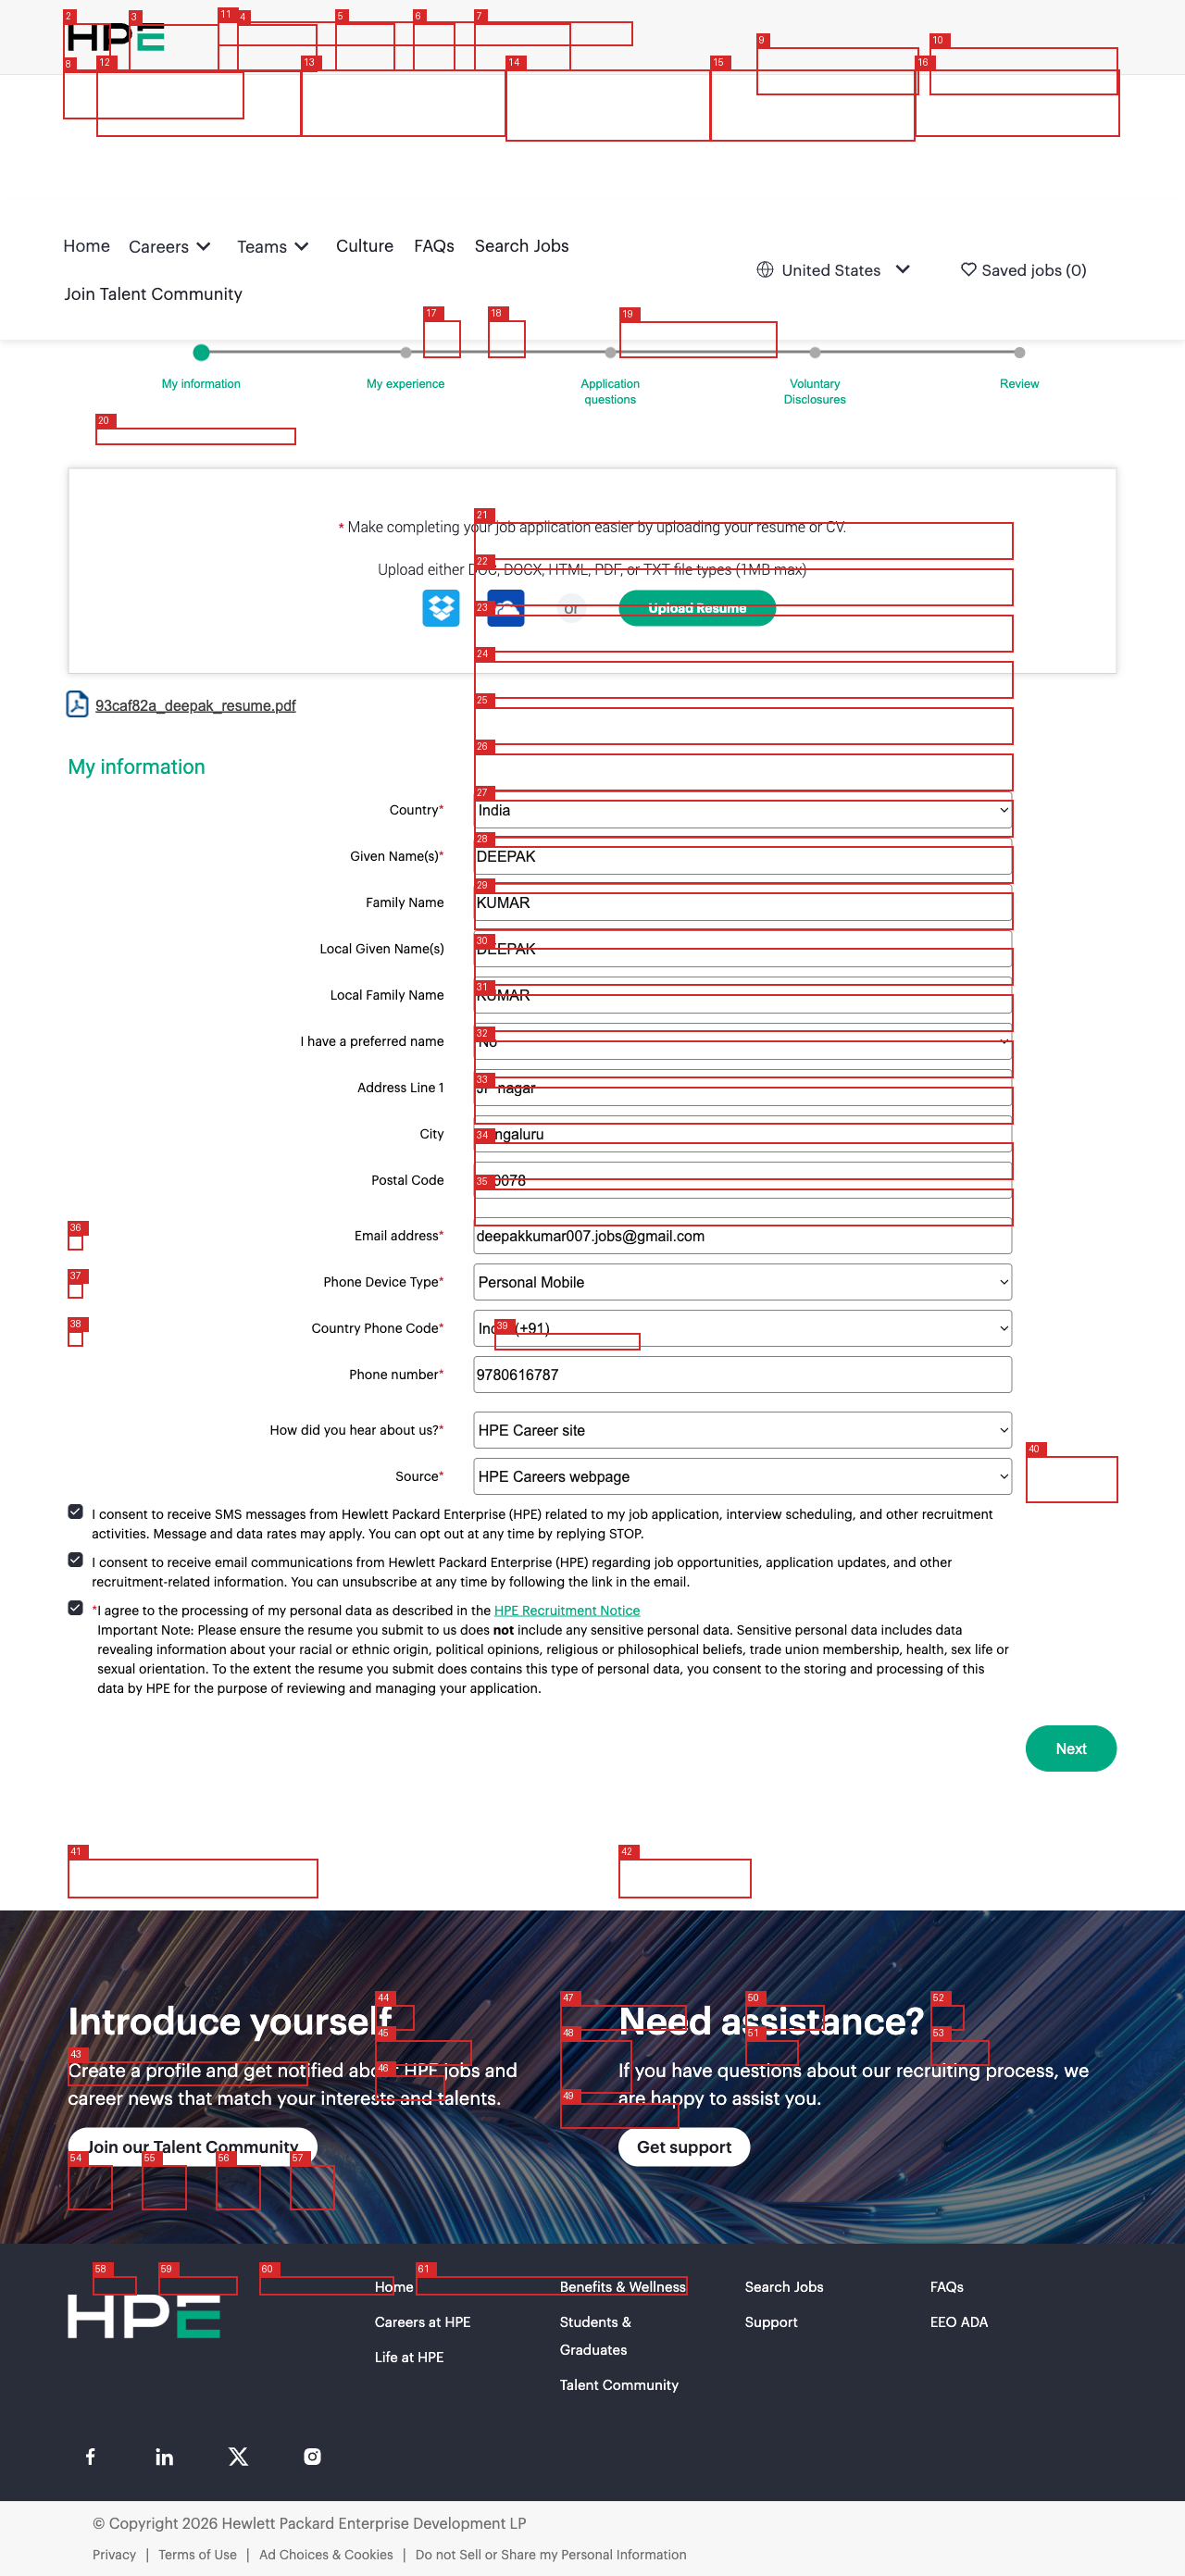

In [12]:
# ── Vision audit (READ-ONLY) — catch what the DOM can't ───────────────────
# converge_page only fixes what the PAGE flags (validation errors). It cannot
# catch a value that filled "successfully" but is semantically WRONG — e.g. you
# typed India and the typeahead snapped to Pakistan: valid value, no error,
# silently incorrect. This cell takes a FULL-PAGE screenshot and asks the LLM to
# compare what is VISIBLE against your profile.
#   READ-ONLY: it REPORTS, it changes nothing. Run AFTER the convergence cell.
import base64 as _b64a
import apply_engine as _ae

R(page.evaluate("window.scrollTo(0, 0)")); R(page.wait_for_timeout(400))
_elems_a, _ = R(collect_elements(page))
_ae._assign_section_rows(_elems_a)              # so row labels show in the audit
_raw_a  = R(page.screenshot(full_page=True))
_mark_a = annotate_screenshot(_raw_a, _elems_a)

prof_a = load_profile(globals().get("USER_ID", 1))
_pctx  = _ae._profile_ctx(prof_a)               # trimmed profile = ground truth

AUDIT_PROMPT = f"""You are QA-checking a half-filled job-application page before submission.
Red numbered boxes mark interactive fields (the number is each field's index).

CANDIDATE PROFILE (ground truth):
{_pctx}

Report ONLY genuine problems. MOST FIELDS WILL BE CORRECT — returning empty
arrays is the normal, expected result. Bias HARD toward "ok": when unsure, do
NOT report a field.

Return STRICT JSON:
{{
  "ok": <true if no real problems>,
  "wrong":   [{{"index": <int>, "field": "<label>", "shown": "<current value>", "should_be": "<correct value from profile>", "why": "<short>"}}],
  "missing": [{{"index": <int>, "field": "<label>"}}],
  "errors":  ["<inline red error text visible on the page>"]
}}

WRONG — include a field ONLY if its visible value CONTRADICTS the profile in
MEANING (Country shows 'Pakistan' but profile says India; a misspelled name; a
wrong date; a dropdown snapped to the wrong option). The following are NOT wrong
— NEVER report them:
  - the same value in different casing / spacing / punctuation,
  - a formatting variant ('India (+91)' == India; '12/2022' == Dec 2022),
  - an acceptable synonym or more-specific value ('Personal Mobile' is fine for a
    Mobile phone type),
  - a value that simply isn't in the profile (you cannot judge it — skip it).
  Before adding ANY field, confirm shown and should_be mean DIFFERENT things.
  If they are equal or equivalent, OMIT the field. Do not add a field just to
  note that it matches.
  Focus on dropdowns / typeaheads / dates — those snap to wrong values without
  the page erroring.

MISSING — a field with a clear visible label, marked required (*), that is empty
or still shows a placeholder ('Please Select'). Do NOT invent fields; if you
can't read a clear label, skip it. NEVER output 'Unknown required field'. The
resume-upload area is not a missing field.

ERRORS — copy any inline red error text actually visible on the page.

Refer to fields by their red index number. Return ONLY the JSON object."""

audit = llm_json(AUDIT_PROMPT, image_b64=_b64a.b64encode(_mark_a).decode(),
                 gemini_client=gemini_client, gemini_model=FLASH_MODEL) or {}

# Client-side guard: drop any "wrong" whose shown == should_be after normalizing
# (alnum-only, lowercase) — kills residual false positives like India/India and
# 'India (+91)' / 'India +91'. The model SHOULD already omit these.
def _norm_a(s):
    return "".join(ch for ch in str(s or "").lower() if ch.isalnum())
wrong = [w for w in (audit.get("wrong") or [])
         if _norm_a(w.get("shown")) != _norm_a(w.get("should_be"))]
missing = audit.get("missing") or []
errors  = audit.get("errors") or []

print("=" * 60)
print(f"  VISION AUDIT   real_issues={'no' if not (wrong or missing or errors) else 'YES'}"
      f"   (model_ok={audit.get('ok')})")
print("=" * 60)
for w in wrong:
    print(f"  WRONG   [{w.get('index')}] {w.get('field')}: "
          f"shown={w.get('shown')!r} -> should_be={w.get('should_be')!r}  ({w.get('why','')})")
for m in missing:
    print(f"  MISSING [{m.get('index')}] {m.get('field')}")
for e in errors:
    print(f"  ERROR   {e}")
if not (wrong or missing or errors):
    print("  (clean — visible values match the profile, nothing missing/errored)")
_dropped = len(audit.get('wrong') or []) - len(wrong)
if _dropped:
    print(f"  [guard dropped {_dropped} false-positive 'wrong' where shown == should_be]")

display(Image(data=_mark_a))

## 10. Held fields — confirm a choice the engine wasn't sure about

When `converge_page` can't confidently resolve a dropdown or free-text answer it
**holds** it and prints a ready-to-paste line. Paste it into a NEW cell, edit the
value, run it, then `save_profile(USER_ID, profile)` and re-run the convergence
cell. The cached answer is reused on every future run.

```python
resolve_field(profile, "<field label>", "<profile value or empty>", "<the option/answer>")
save_profile(USER_ID, profile)
```

## 11. Cleanup

Close the browser when you're done. Skip if you want to keep poking — you can
re-run the scan / gateway / reveal / converge cells to watch the page evolve.

In [13]:
# R(ctx.close())
# R(_p.stop())
# print("Closed.")
